# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset diperoleh dari public repositories Kaggle. Telco Customer Churn meliputi kustomer yang keluar per bulan terakhir, layanan yang dipakai kustomer, informasi akun kustomer, dan info demografis kustomer (https://www.kaggle.com/datasets/blastchar/telco-customer-churn).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
#Type your code here
!pip install mlflow
import mlflow
print("MLflow version:", mlflow.__version__)


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


MLflow version: 3.5.1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import joblib

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
#Type your code here
file_id = '1774PlfM5m-nuYLl8RUEzFctN1se3r3ku'
url= f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url)

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

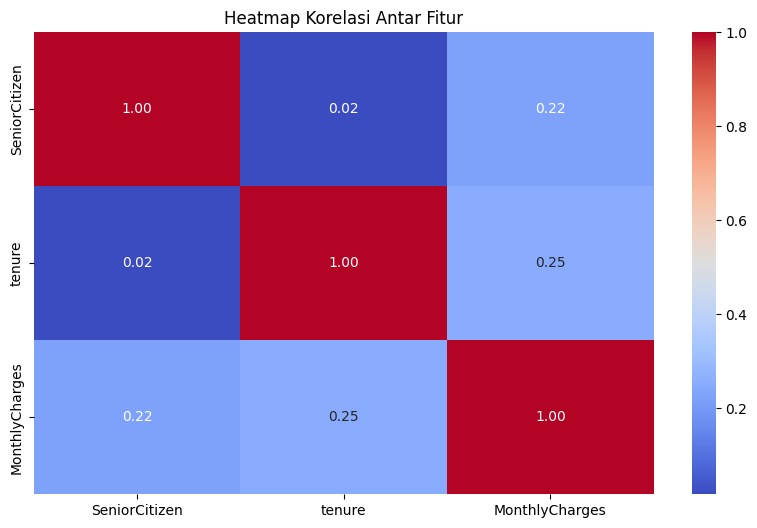

In [9]:
#Type your code here
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

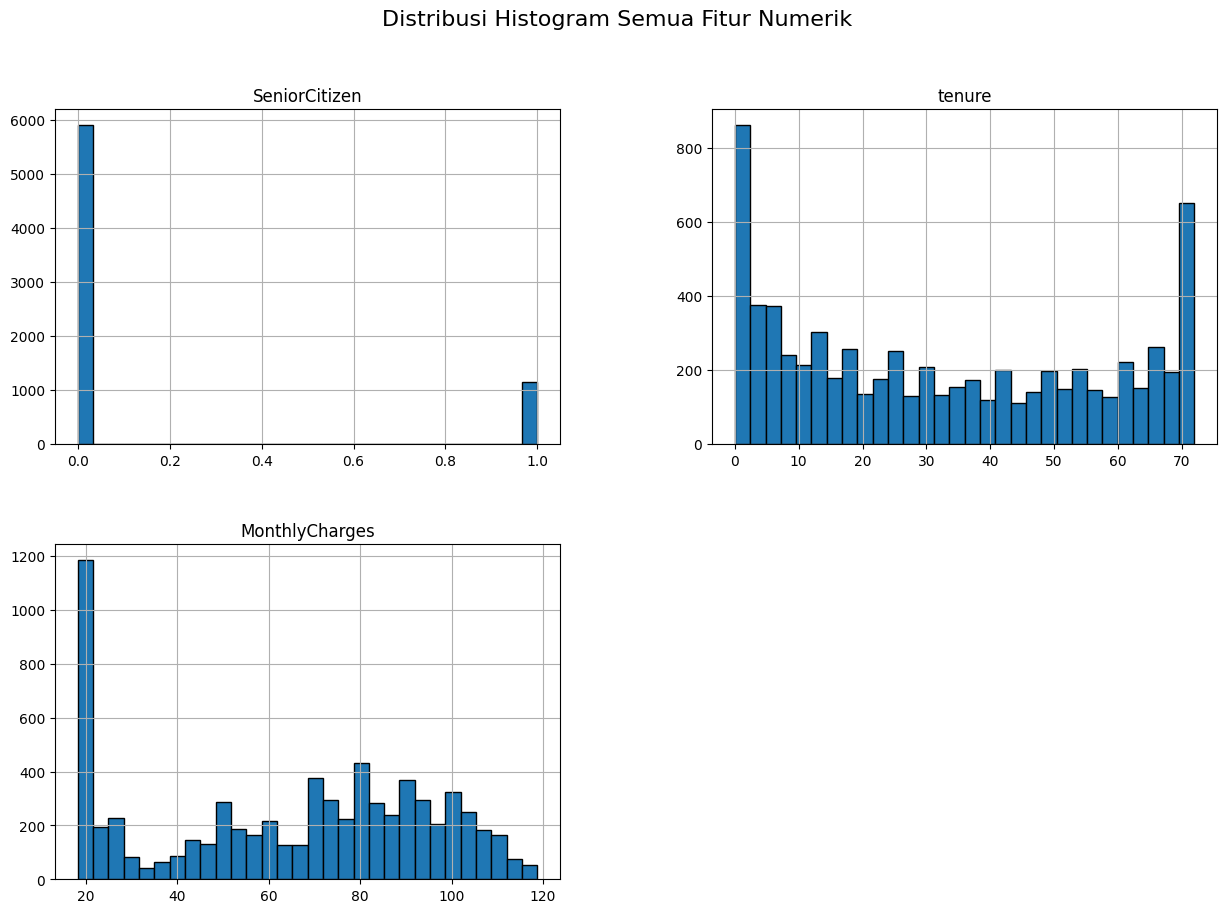

In [10]:
df.hist(figsize=(15, 10), bins=30, edgecolor="black")
plt.suptitle("Distribusi Histogram Semua Fitur Numerik", fontsize=16)
plt.show()

In [11]:
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(include=['object', 'category']).columns

exclude_cols = ['customerID', 'TotalCharges']
cat_cols = [col for col in cat_cols if col not in exclude_cols]

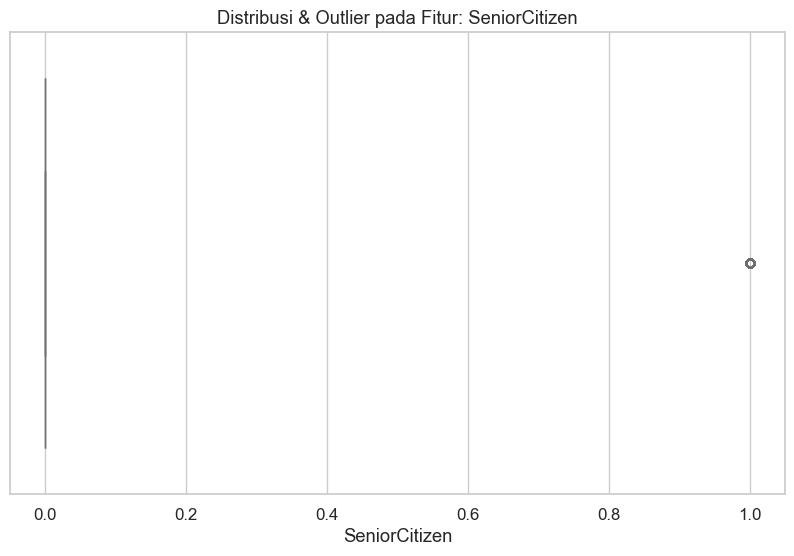

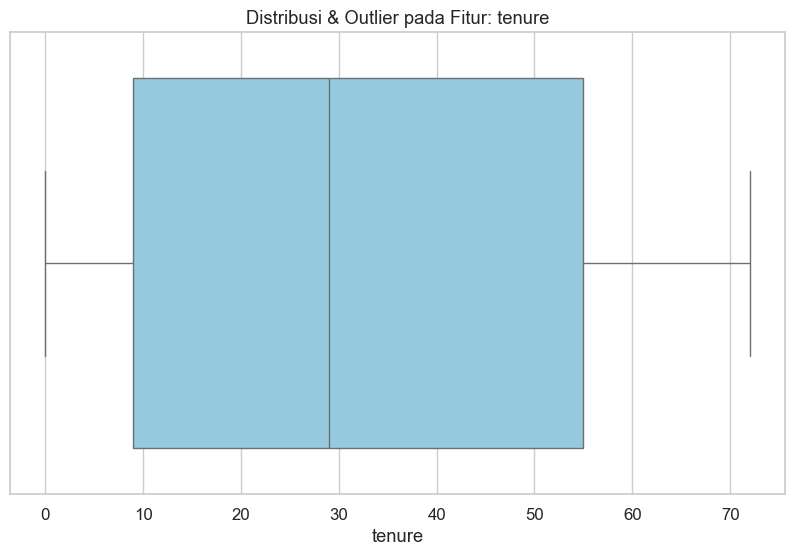

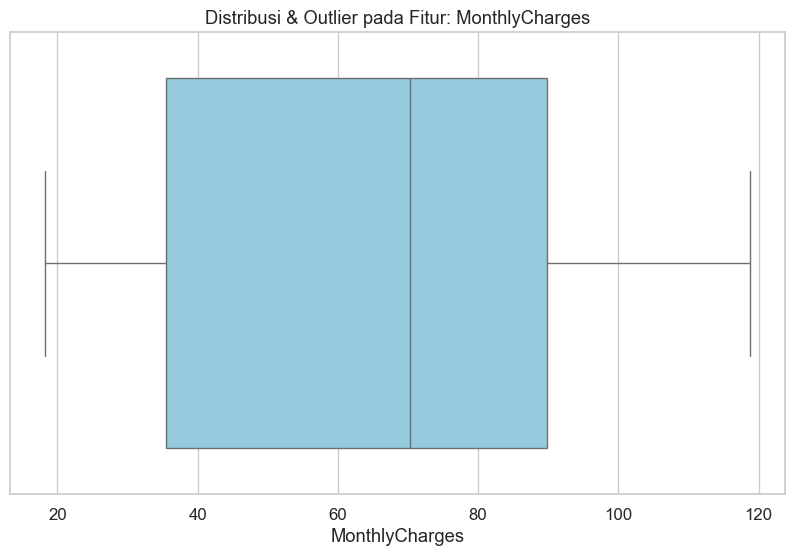

In [12]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Distribusi & Outlier pada Fitur: {col}")
    plt.xlabel(col)
    plt.show()

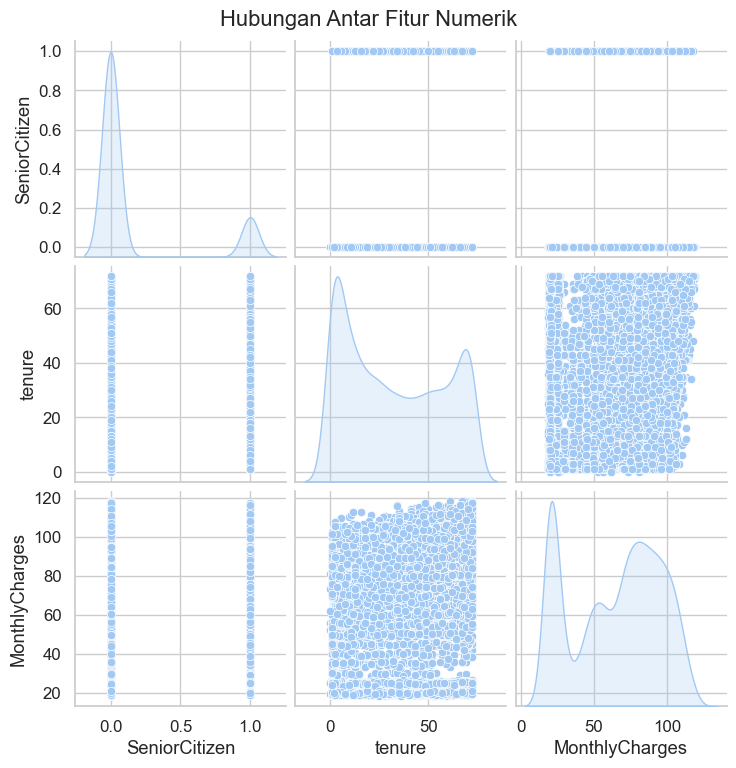

In [49]:
sns.pairplot(df[num_cols], diag_kind='kde')
plt.suptitle("Hubungan Antar Fitur Numerik", y=1.02)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


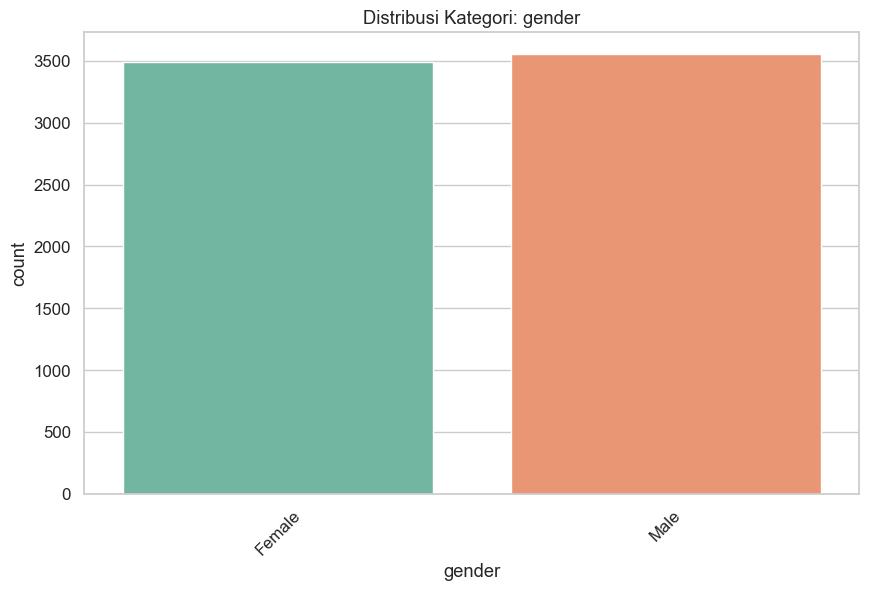

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


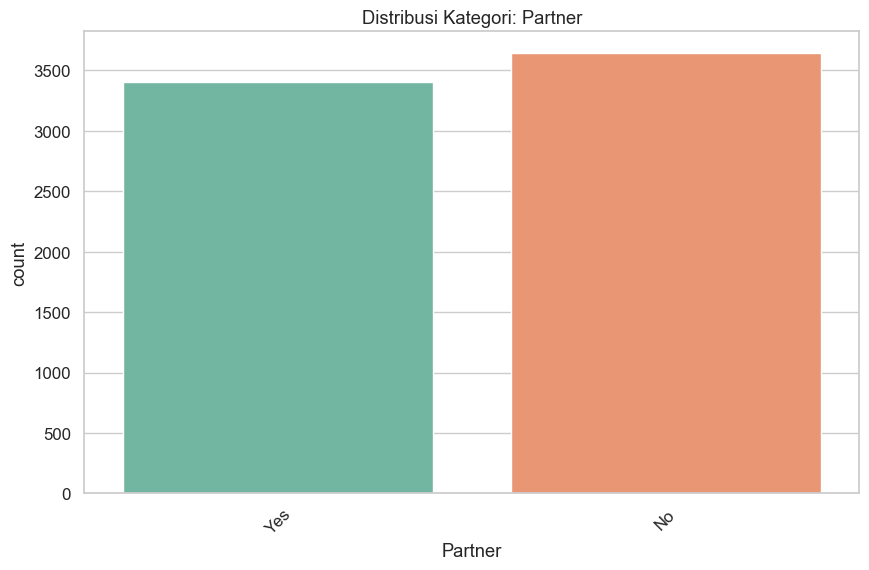

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


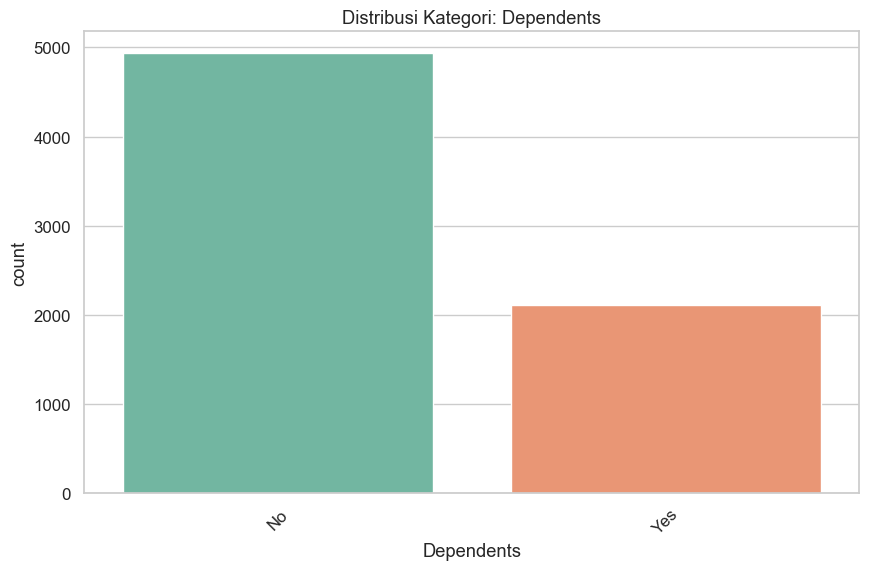

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


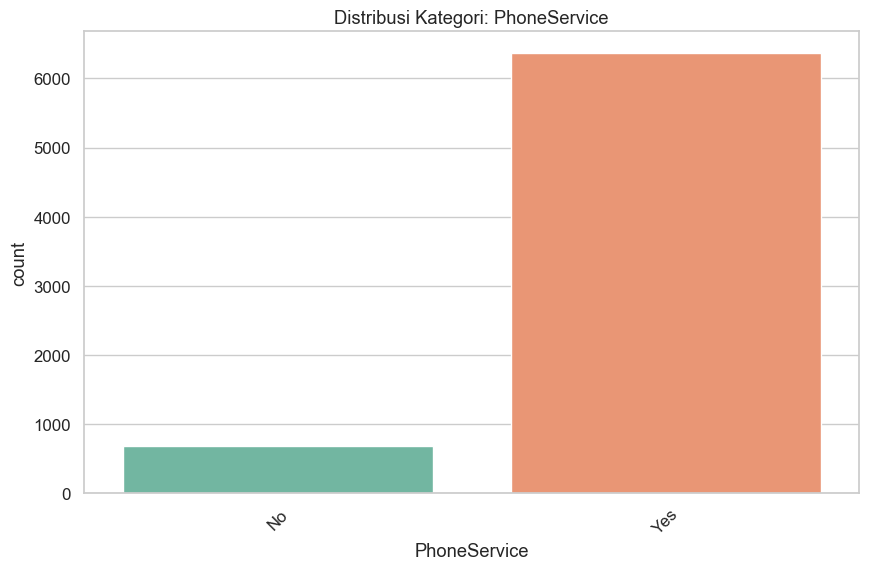

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


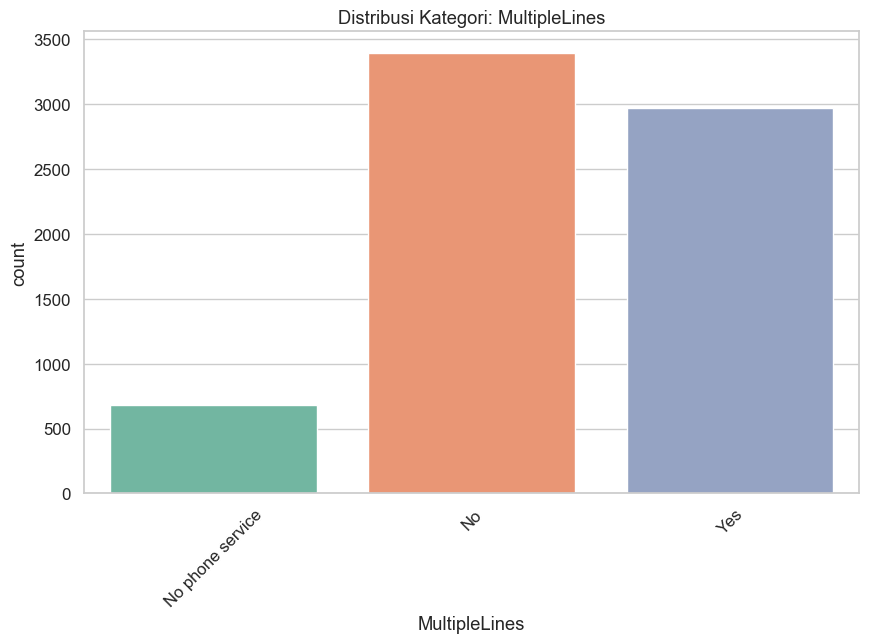

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


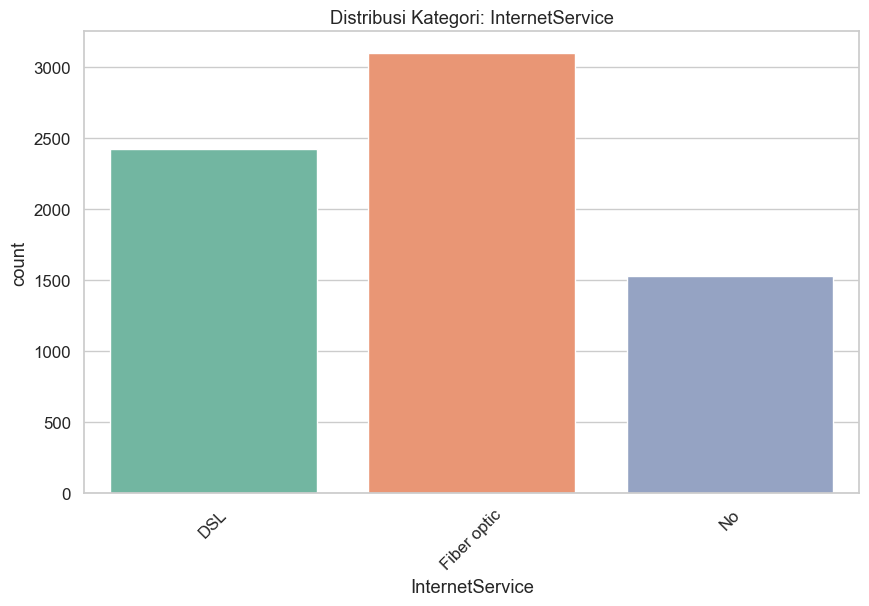

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


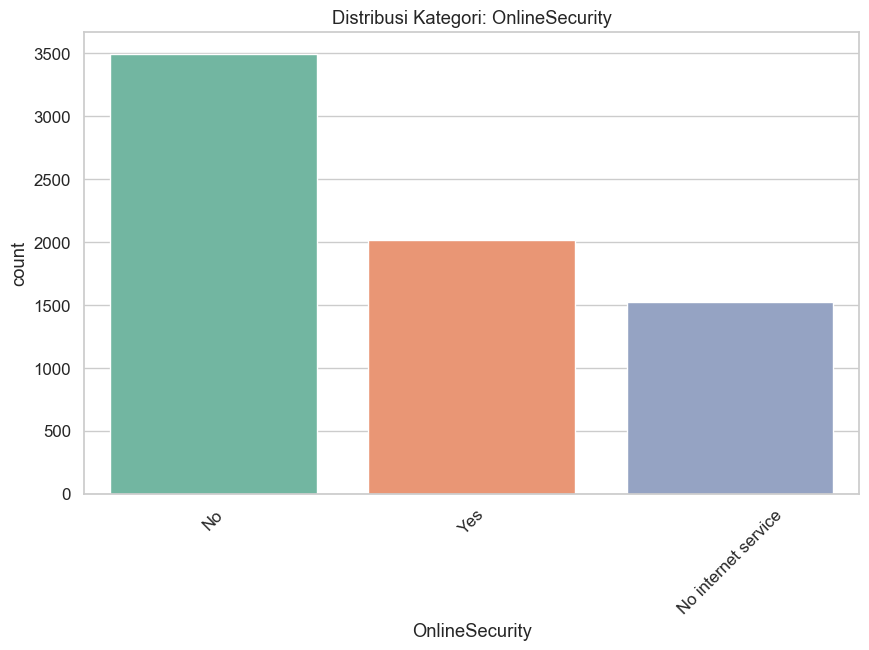

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


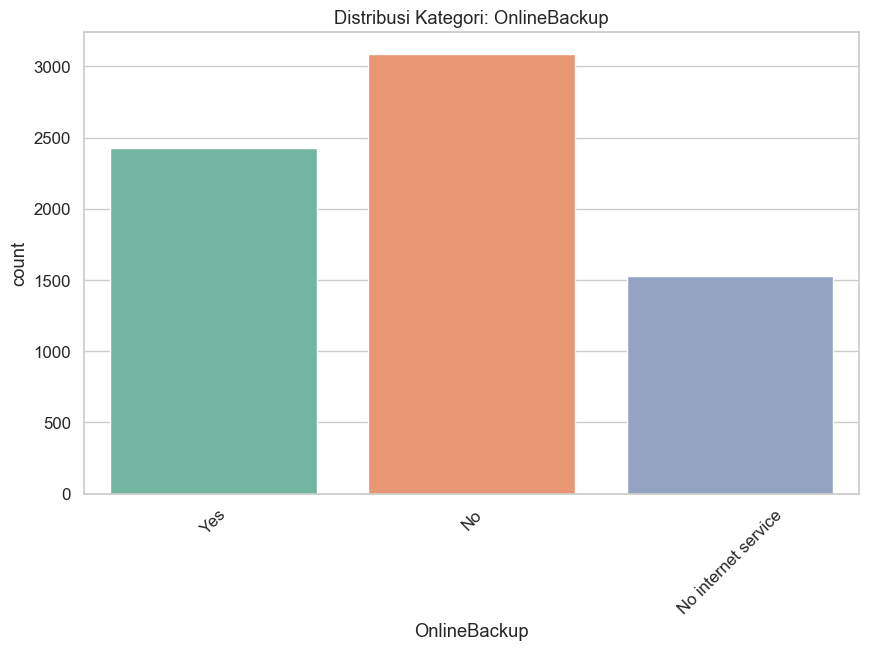

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


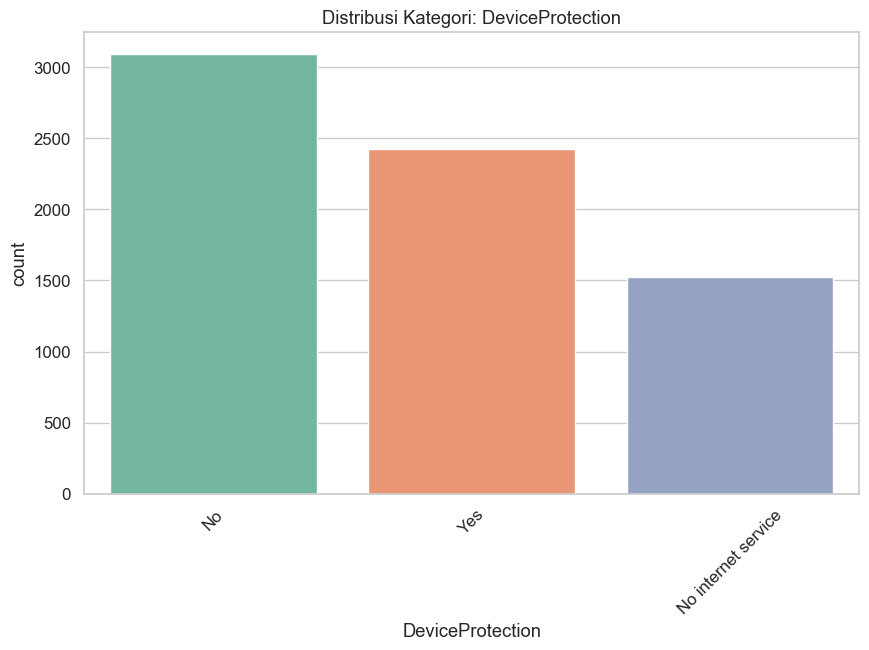

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


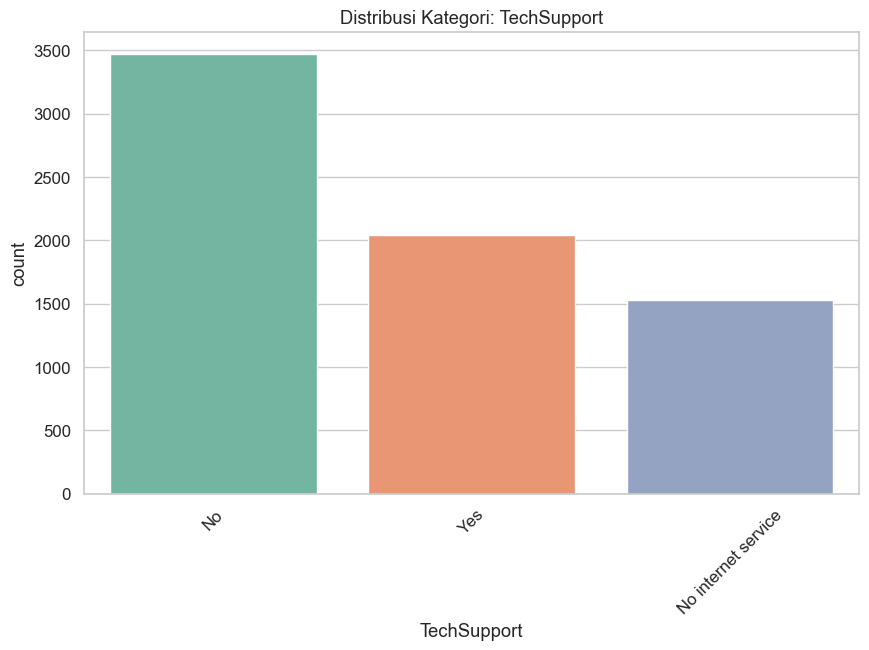

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


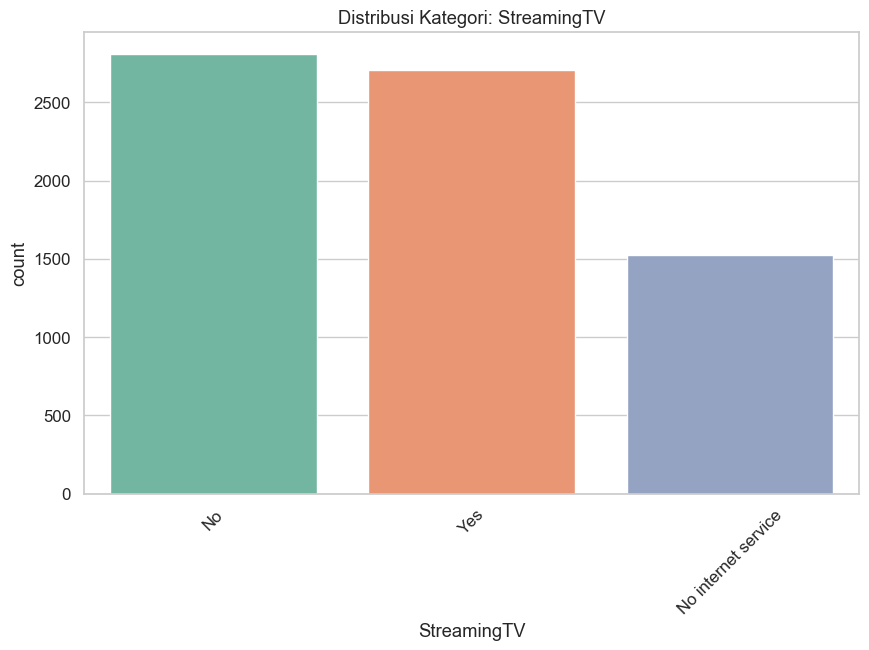

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


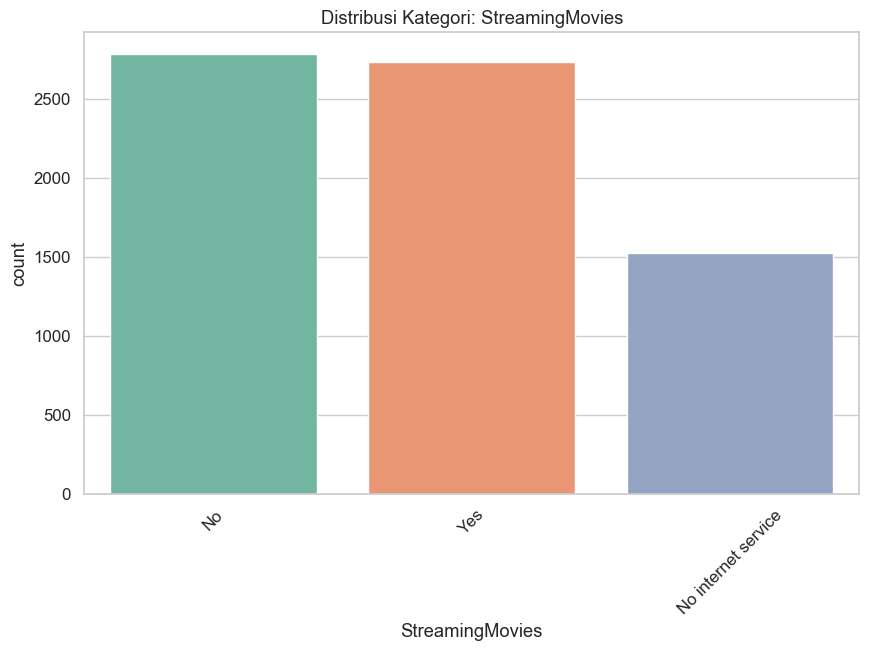

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


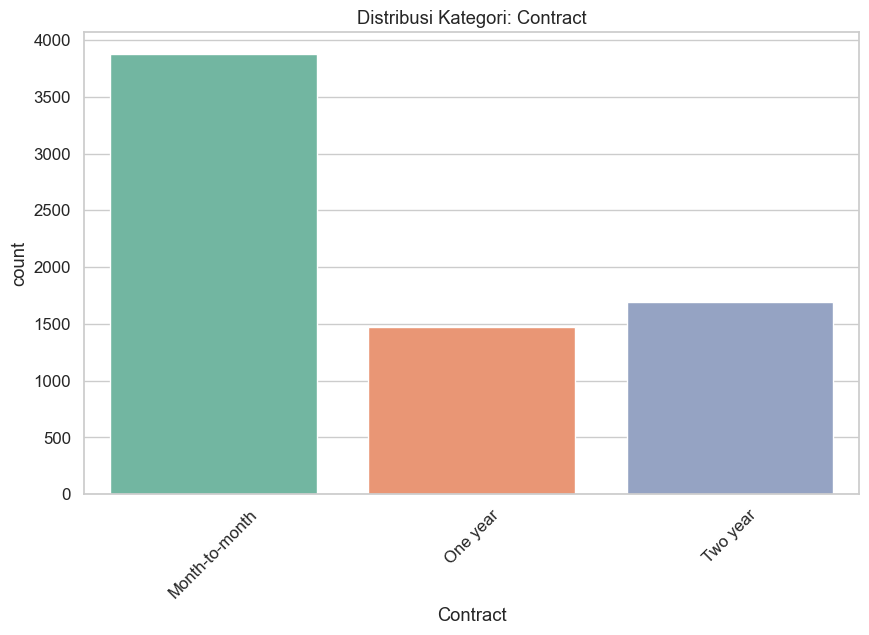

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


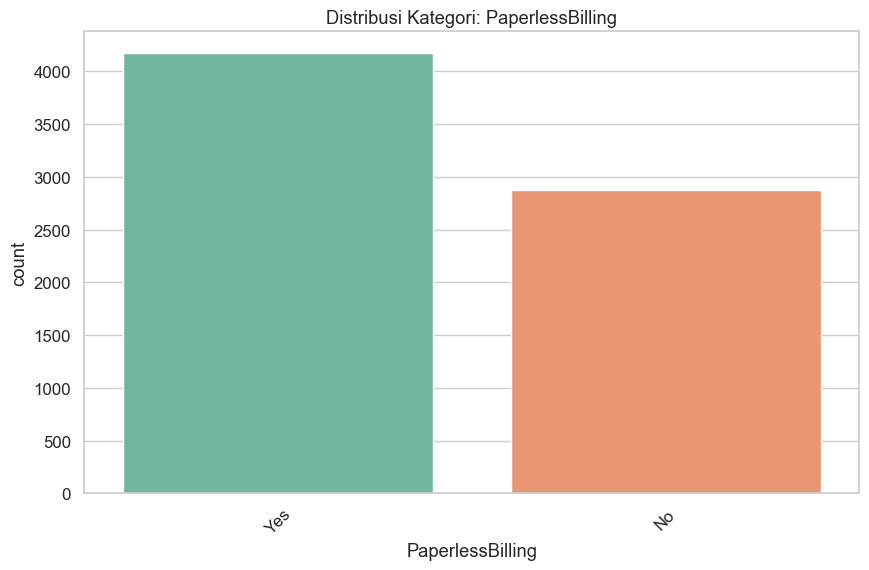

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


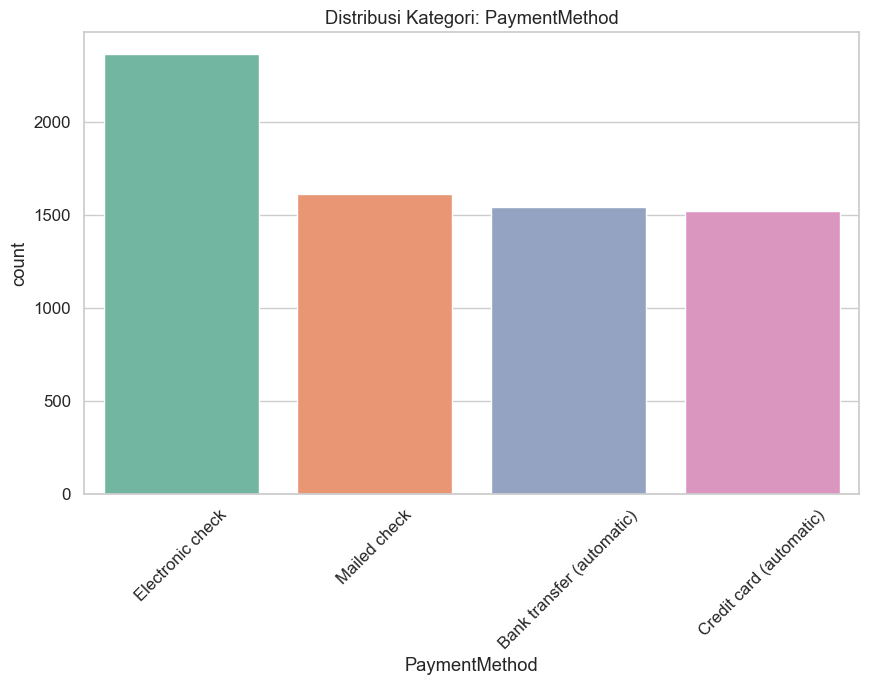

C:\Users\User\AppData\Local\Temp\ipykernel_21852\555106655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


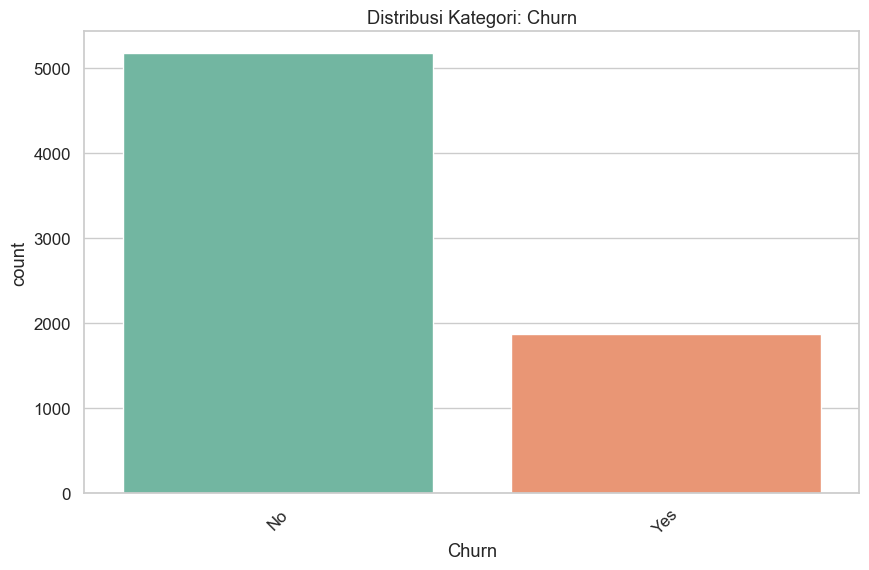

In [50]:
for col in cat_cols:
    plt.figure()
    sns.countplot(data=df, x=col, palette="Set2")
    plt.title(f"Distribusi Kategori: {col}")
    plt.xticks(rotation=45)
    plt.show()

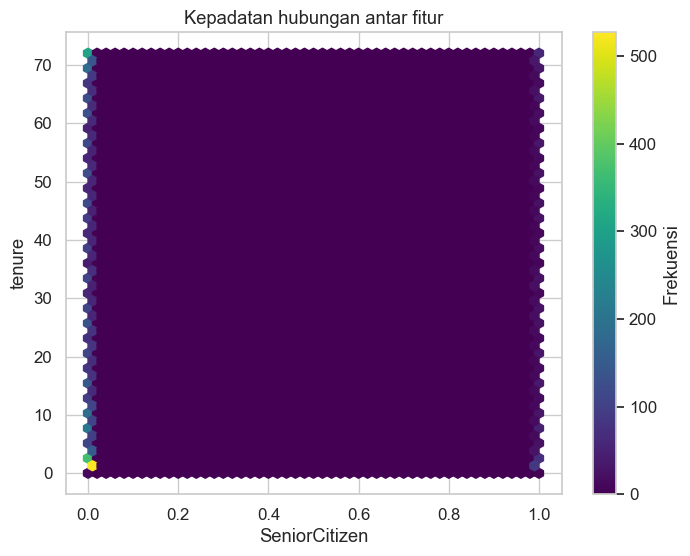

In [13]:
plt.figure(figsize=(8,6))
plt.hexbin(df[num_cols[0]], df[num_cols[1]], gridsize=50, cmap="viridis")
plt.xlabel(num_cols[0])
plt.ylabel(num_cols[1])
plt.title("Kepadatan hubungan antar fitur")
plt.colorbar(label='Frekuensi')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_7676\195361661.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=cat_cols[0], y='tenure', ci=None, palette="coolwarm")
C:\Users\User\AppData\Local\Temp\ipykernel_7676\195361661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=cat_cols[0], y='tenure', ci=None, palette="coolwarm")


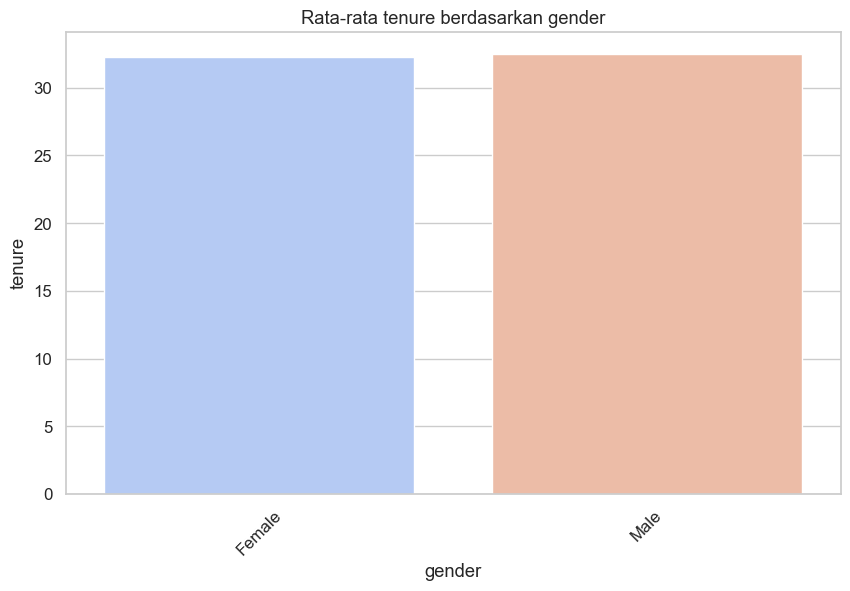

In [14]:
if len(cat_cols) > 0 and 'tenure' in df.columns:
    plt.figure()
    sns.barplot(data=df, x=cat_cols[0], y='tenure', ci=None, palette="coolwarm")
    plt.title(f"Rata-rata tenure berdasarkan {cat_cols[0]}")
    plt.xticks(rotation=45)
    plt.show()

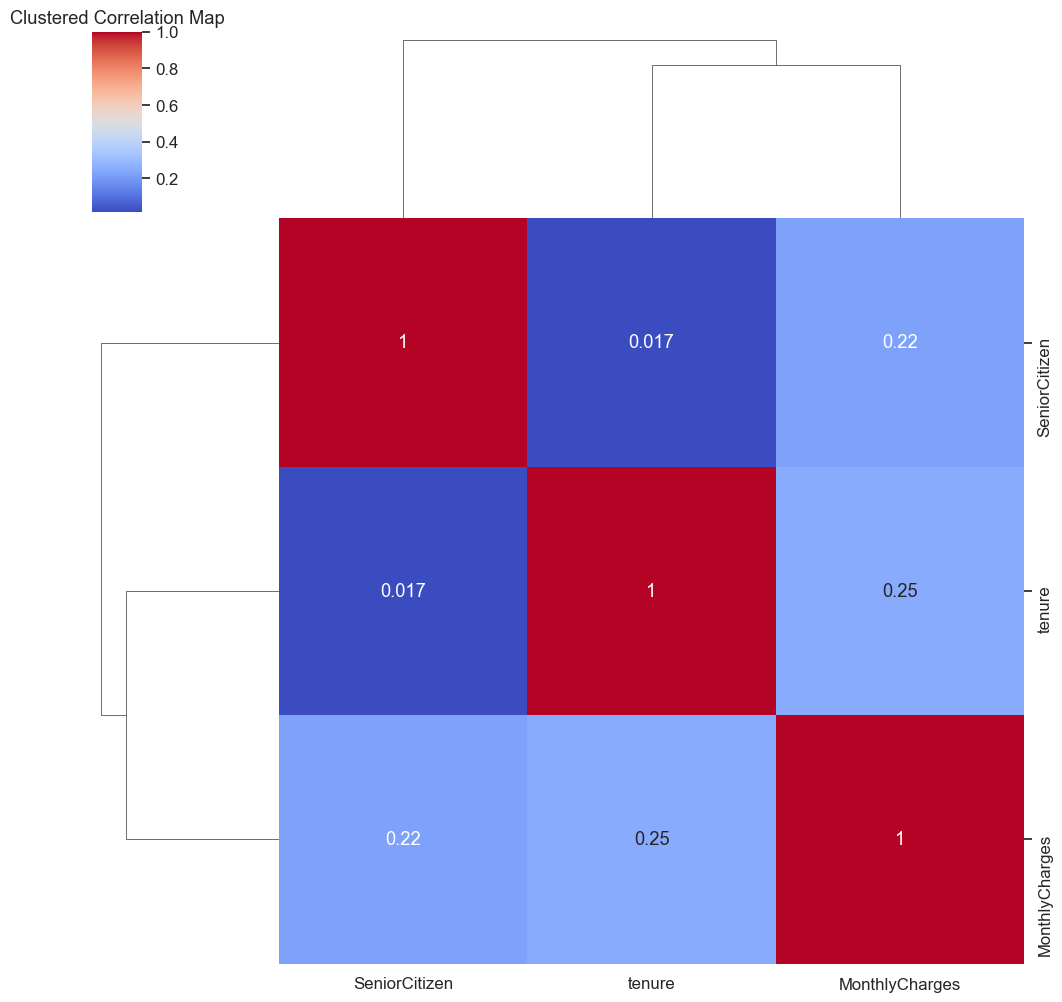

In [53]:
corr = df[num_cols].corr()
sns.clustermap(corr, cmap="coolwarm", annot=True)
plt.title("Clustered Correlation Map")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
# Menangani Data Kosong
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

print("Jumlah dan persentase missing values per kolom:\n")
print(pd.concat([missing_count, missing_percent.round(2)], axis=1, keys=['Jumlah', 'Persentase (%)']))
print("\n")

for col in df.columns:
    if missing_percent[col] > 0:  
        if missing_percent[col] < 5:
            df = df[df[col].notnull()]
            print(f"Kolom '{col}' punya {missing_percent[col]:.2f}% missing → baris dengan nilai kosong dihapus.")
        else:
            if df[col].dtype in ['float64', 'int64']:
                imputer = SimpleImputer(strategy='median')
            else:
                imputer = SimpleImputer(strategy='most_frequent')
            
            df[[col]] = imputer.fit_transform(df[[col]])
            print(f"Kolom '{col}' punya {missing_percent[col]:.2f}% missing → nilai kosong diimputasi ({imputer.strategy_}).")

print("\n✅ Penanganan missing values selesai!\n")
print("Cek ulang missing values:")
print(df.isnull().sum())


Jumlah dan persentase missing values per kolom:

                  Jumlah  Persentase (%)
customerID             0             0.0
gender                 0             0.0
SeniorCitizen          0             0.0
Partner                0             0.0
Dependents             0             0.0
tenure                 0             0.0
PhoneService           0             0.0
MultipleLines          0             0.0
InternetService        0             0.0
OnlineSecurity         0             0.0
OnlineBackup           0             0.0
DeviceProtection       0             0.0
TechSupport            0             0.0
StreamingTV            0             0.0
StreamingMovies        0             0.0
Contract               0             0.0
PaperlessBilling       0             0.0
PaymentMethod          0             0.0
MonthlyCharges         0             0.0
TotalCharges           0             0.0
Churn                  0             0.0



✅ Penanganan missing values selesai!

Cek ulan

In [16]:
# Menghapus Data Duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat sebelum dihapus: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ {duplicates} baris duplikat berhasil dihapus.")
else:
    print("Tidak ditemukan data duplikat.")

print(f"Jumlah baris data setelah pembersihan: {len(df)}")

Jumlah data duplikat sebelum dihapus: 0
Tidak ditemukan data duplikat.
Jumlah baris data setelah pembersihan: 7043


Kolom numerik yang akan diproses: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

✅ Normalisasi dan Standarisasi telah diterapkan.
Data hasil normalisasi disimpan di df_normalized
Data hasil standarisasi disimpan di df_standardized


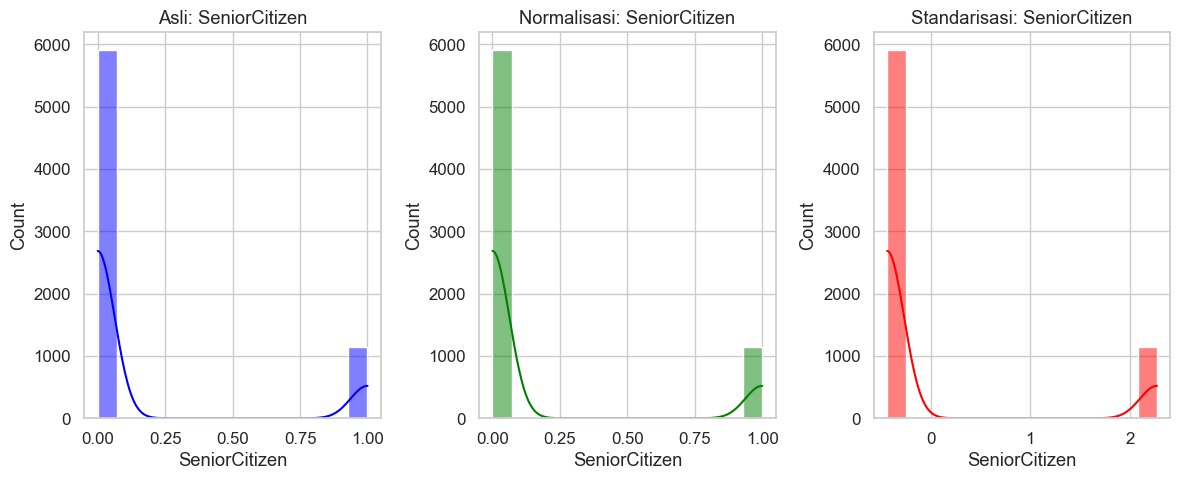

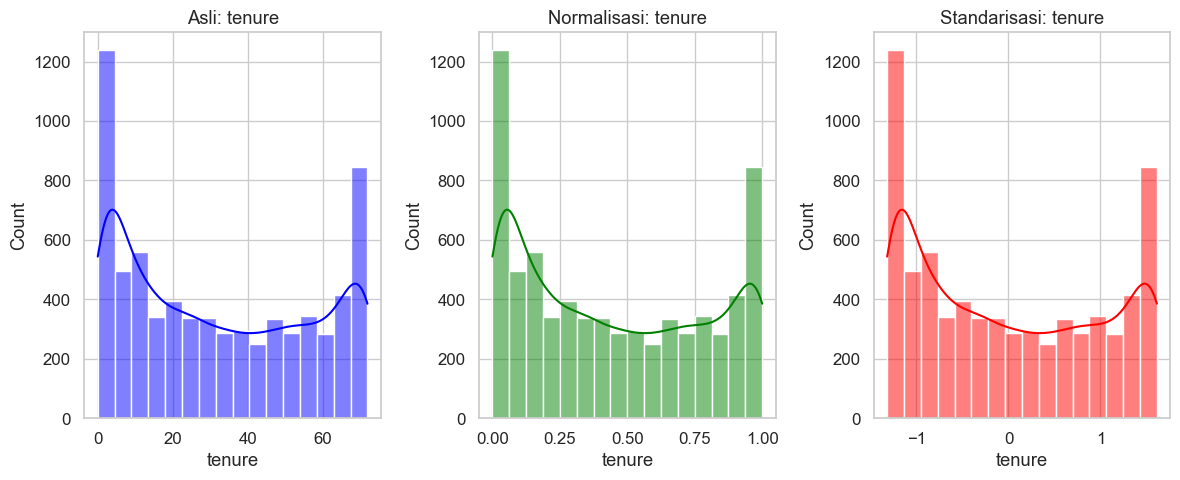

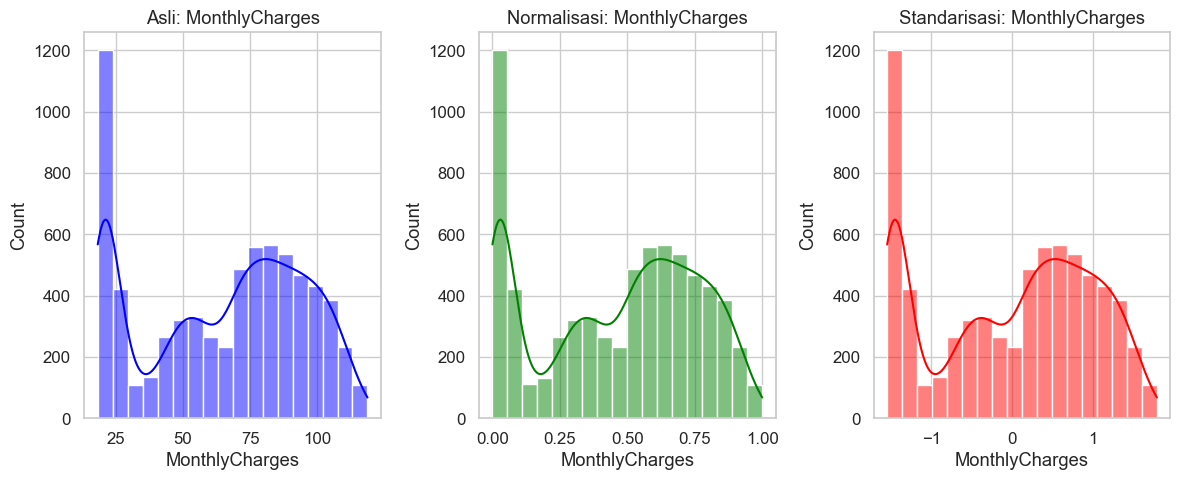

In [17]:
# Normalisasi atau Standarisasi Fitur
print("Kolom numerik yang akan diproses:", list(num_cols))

minmax_scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[num_cols] = minmax_scaler.fit_transform(df[num_cols])

standard_scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[num_cols] = standard_scaler.fit_transform(df[num_cols])

print("\n✅ Normalisasi dan Standarisasi telah diterapkan.")
print("Data hasil normalisasi disimpan di df_normalized")
print("Data hasil standarisasi disimpan di df_standardized")

for col in num_cols:
    plt.figure(figsize=(12, 5))
    
    # Asli
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f"Asli: {col}")

    # Normalisasi
    plt.subplot(1, 3, 2)
    sns.histplot(df_normalized[col], kde=True, color='green')
    plt.title(f"Normalisasi: {col}")

    # Standarisasi
    plt.subplot(1, 3, 3)
    sns.histplot(df_standardized[col], kde=True, color='red')
    plt.title(f"Standarisasi: {col}")

    plt.tight_layout()
    plt.show()

Kolom numerik yang akan diperiksa: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

📊 Kolom: SeniorCitizen
Jumlah outlier: 1142 (16.21%)
Rentang normal: [0.00, 0.00]


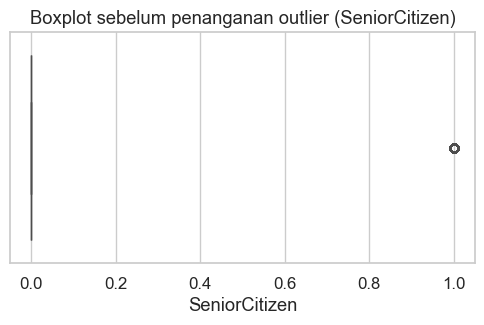


📊 Kolom: tenure
Jumlah outlier: 0 (0.00%)
Rentang normal: [-60.00, 124.00]


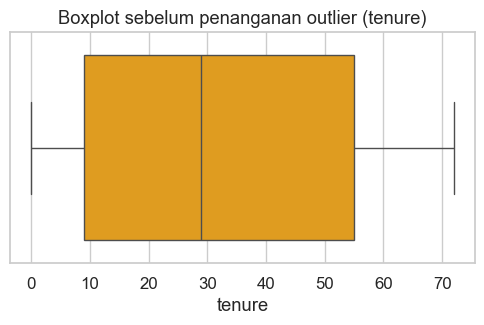


📊 Kolom: MonthlyCharges
Jumlah outlier: 0 (0.00%)
Rentang normal: [-46.02, 171.38]


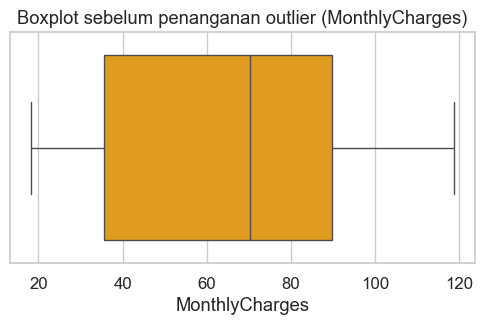

⚙️ SeniorCitizen: Outlier >=5%, dilakukan winsorizing (dibatasi ke batas bawah/atas).
✅ tenure: Outlier <5%, data outlier dihapus.
✅ MonthlyCharges: Outlier <5%, data outlier dihapus.

🎯 Penanganan outlier selesai. Data tersimpan di variabel df_cleaned.


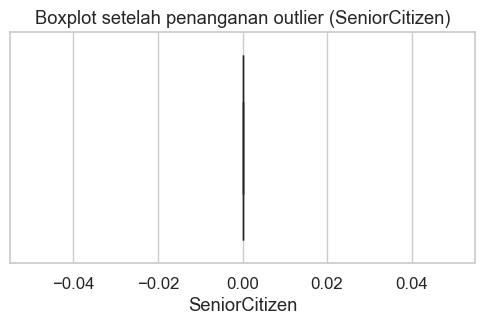

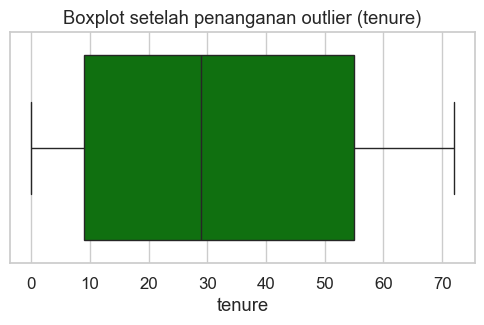

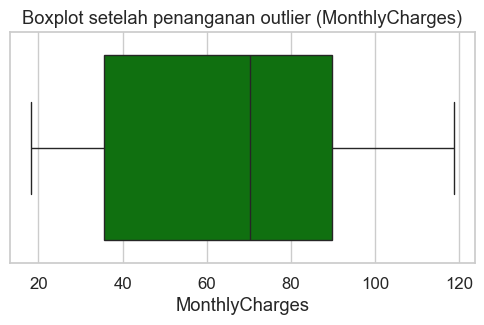

In [18]:
# Deteksi dan Penanganan Outlier
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Kolom numerik yang akan diperiksa:", list(num_cols))

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in num_cols:
    outliers, low, up = detect_outliers_iqr(df, col)
    n_outliers = len(outliers)
    perc = (n_outliers / len(df)) * 100

    print(f"\n📊 Kolom: {col}")
    print(f"Jumlah outlier: {n_outliers} ({perc:.2f}%)")
    print(f"Rentang normal: [{low:.2f}, {up:.2f}]")

    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f"Boxplot sebelum penanganan outlier ({col})")
    plt.show()

df_cleaned = df.copy()

for col in num_cols:
    outliers, low, up = detect_outliers_iqr(df, col)
    perc = (len(outliers) / len(df)) * 100
    
    if perc < 5:
        df_cleaned = df_cleaned[(df_cleaned[col] >= low) & (df_cleaned[col] <= up)]
        print(f"✅ {col}: Outlier <5%, data outlier dihapus.")
    else:
        df_cleaned[col] = np.where(df_cleaned[col] < low, low,
                            np.where(df_cleaned[col] > up, up, df_cleaned[col]))
        print(f"⚙️ {col}: Outlier >=5%, dilakukan winsorizing (dibatasi ke batas bawah/atas).")

print("\n🎯 Penanganan outlier selesai. Data tersimpan di variabel df_cleaned.")

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df_cleaned[col], color='green')
    plt.title(f"Boxplot setelah penanganan outlier ({col})")
    plt.show()


In [19]:
# Encoding Data Kategorikal
print("Kolom kategorikal yang terdeteksi:", list(cat_cols))

for col in cat_cols:
    print(f"\n📊 {col}: {df[col].nunique()} kategori")
    print(df[col].unique())

df_encoded = df.copy()

for col in cat_cols:
    unique_count = df[col].nunique()
    if unique_count <= 2:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col])
        print(f"✅ {col}: menggunakan Label Encoding")
    elif unique_count < 10:
        encoded_cols = pd.get_dummies(df_encoded[col], prefix=col)
        df_encoded = pd.concat([df_encoded.drop(col, axis=1), encoded_cols], axis=1)
        print(f"✅ {col}: menggunakan One-Hot Encoding ({unique_count} kategori)")
    else:
        freq_encoding = df[col].value_counts(normalize=True)
        df_encoded[col] = df[col].map(freq_encoding)
        print(f"⚙️ {col}: menggunakan Frequency Encoding ({unique_count} kategori)")

print("\n🎯 Encoding selesai. Data tersimpan di variabel df_encoded.")

Kolom kategorikal yang terdeteksi: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

📊 gender: 2 kategori
['Female' 'Male']

📊 Partner: 2 kategori
['Yes' 'No']

📊 Dependents: 2 kategori
['No' 'Yes']

📊 PhoneService: 2 kategori
['No' 'Yes']

📊 MultipleLines: 3 kategori
['No phone service' 'No' 'Yes']

📊 InternetService: 3 kategori
['DSL' 'Fiber optic' 'No']

📊 OnlineSecurity: 3 kategori
['No' 'Yes' 'No internet service']

📊 OnlineBackup: 3 kategori
['Yes' 'No' 'No internet service']

📊 DeviceProtection: 3 kategori
['No' 'Yes' 'No internet service']

📊 TechSupport: 3 kategori
['No' 'Yes' 'No internet service']

📊 StreamingTV: 3 kategori
['No' 'Yes' 'No internet service']

📊 StreamingMovies: 3 kategori
['No' 'Yes' 'No internet service']

📊 Contract: 3 kategori
['Month-to-month' 'One year' 'Tw

In [20]:
# Binning (Pengelompokan Data)
print("Kolom numerik yang terdeteksi:", list(num_cols))

df_binned = df.copy()

n_bins = 3 

for col in num_cols:
    unique_vals = df[col].nunique()

    if unique_vals <= 1:
        print(f"⚠️ Kolom {col} dilewati (hanya 1 nilai unik).")
        continue

    if unique_vals > n_bins:
        try:
            df_binned[col + '_bin_width'] = pd.cut(df[col], bins=n_bins, labels=['Rendah', 'Sedang', 'Tinggi'])
            
            df_binned[col + '_bin_freq'] = pd.qcut(df[col], q=n_bins, labels=['Rendah', 'Sedang', 'Tinggi'], duplicates='drop')
            
            print(f"✅ {col}: berhasil dibinning ({col}_bin_width & {col}_bin_freq)")
        
        except Exception as e:
            print(f"⚠️ Kolom {col} dilewati karena error saat binning: {e}")
    else:
        print(f"ℹ️ Kolom {col} tidak cukup variasi nilai ({unique_vals} nilai unik). Dilewati.")

print("\n🎯 Binning selesai. Data tersimpan di variabel df_binned.")

Kolom numerik yang terdeteksi: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
ℹ️ Kolom SeniorCitizen tidak cukup variasi nilai (2 nilai unik). Dilewati.
✅ tenure: berhasil dibinning (tenure_bin_width & tenure_bin_freq)
✅ MonthlyCharges: berhasil dibinning (MonthlyCharges_bin_width & MonthlyCharges_bin_freq)

🎯 Binning selesai. Data tersimpan di variabel df_binned.


In [21]:
# Menyimpan Hasil Data Pre-processing

import os

output_dir = "Telco-Customer-Churn_preprocessing"
os.makedirs(output_dir, exist_ok=True)

# Dataset cleaned (setelah missing value & duplicate & outlier handling)
df_cleaned.to_csv(
    f"{output_dir}/Telco-Customer-Churn_cleaned.csv",
    index=False
)

# Dataset encoded (siap untuk modeling)
df_encoded.to_csv(
    f"{output_dir}/Telco-Customer-Churn_encoded.csv",
    index=False
)

# Dataset normalized
df_normalized.to_csv(
    f"{output_dir}/Telco-Customer-Churn_normalized.csv",
    index=False
)

# Dataset standardized
df_standardized.to_csv(
    f"{output_dir}/Telco-Customer-Churn_standardized.csv",
    index=False
)

# Dataset binned
df_binned.to_csv(
    f"{output_dir}/Telco-Customer-Churn_binned.csv",
    index=False
)

print("✅ Semua dataset hasil preprocessing berhasil disimpan.")
print("📁 Lokasi folder:", output_dir)

✅ Semua dataset hasil preprocessing berhasil disimpan.
📁 Lokasi folder: Telco-Customer-Churn_preprocessing
